In [1]:
# Import Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
from modules import PhysicsInformedSustainabilityModel
from modules import NigerianManufacturingContext
from modules import MultiTaskDataset
from modules import SustainabilityAwareBayesianNN
from modules import SustainabilityAwareLoss
warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Using device: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

🖥️ Using device: cpu


In [2]:
# Load Preprocessed Multi-Task Data
print("Loading preprocessed multi-task data...")

with open('../data/preprocessed_multitask_data.pkl', 'rb') as f:
    data_package = pickle.load(f)

X_train = data_package['X_train']
X_val = data_package['X_val']
X_test = data_package['X_test']
y_train = data_package['y_train']
y_val = data_package['y_val']
y_test = data_package['y_test']
power_states_train = data_package['power_states_train']
power_states_val = data_package['power_states_val']
power_states_test = data_package['power_states_test']

print(f"✅ Data loaded successfully!")
print(f"   Training samples: {X_train.shape[0]}")
print(f"   Validation samples: {X_val.shape[0]}")
print(f"   Test samples: {X_test.shape[0]}")
print(f"   Number of features: {X_train.shape[1]}")
print(f"   Number of tasks: {len(y_train)}")

Loading preprocessed multi-task data...
✅ Data loaded successfully!
   Training samples: 7004
   Validation samples: 1496
   Test samples: 1500
   Number of features: 8
   Number of tasks: 4


In [3]:
# Create datasets
train_dataset = MultiTaskDataset(X_train, y_train, power_states_train)
val_dataset = MultiTaskDataset(X_val, y_val, power_states_val)
test_dataset = MultiTaskDataset(X_test, y_test, power_states_test)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [4]:
# Initialize model
input_size = X_train.shape[1]
model = SustainabilityAwareBayesianNN(
    input_size=input_size,
    hidden_sizes=[128, 64, 32],
    dropout_rate=0.3
).to(device)

print("✅ Multi-Task Bayesian Neural Network created!")
print(f"   Input size: {input_size}")
print(f"   Architecture: {input_size} -> 128 -> 64 -> 32 -> [4 task heads]")
print(f"   Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Initialize loss function
criterion = SustainabilityAwareLoss()


✅ Multi-Task Bayesian Neural Network created!
   Input size: 8
   Architecture: 8 -> 128 -> 64 -> 32 -> [4 task heads]
   Total parameters: 13,800


In [5]:
# Training Functions

def train_epoch(model, train_loader, criterion, optimizer, device): 
    model.train()
    all_losses = []
    
    for batch_x, batch_y, batch_power_states in train_loader:  
        batch_x = batch_x.to(device)
        batch_y = {k: v.to(device) for k, v in batch_y.items()}
        batch_power_states = batch_power_states.to(device)
        
        predictions = model(batch_x)
        
        # Pass power_states to loss function
        loss, loss_dict = criterion(predictions, batch_y, batch_power_states)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        all_losses.append(loss_dict)
    
    # Average all losses for the epoch
    avg_losses = {
        'total': np.mean([l['total'] for l in all_losses]),
        'failure': np.mean([l['failure'] for l in all_losses]),
        'energy': np.mean([l['energy'] for l in all_losses]),
        'emissions': np.mean([l['emissions'] for l in all_losses]),
        'urgency': np.mean([l['urgency'] for l in all_losses]),
        'sustainability': np.mean([l['sustain_total'] for l in all_losses])
    }
    
    return avg_losses

def validate_epoch(model, val_loader, criterion, device):  # Remove epoch parameter
    model.train()
    all_losses = []
    all_uncertainties = []
    
    with torch.no_grad():
        for batch_x, batch_y, batch_power_states in val_loader:  # Unpack power_states
            batch_x = batch_x.to(device)
            batch_y = {k: v.to(device) for k, v in batch_y.items()}
            batch_power_states = batch_power_states.to(device)
            
            # MC Dropout inference for uncertainty
            predictions_list = []
            for _ in range(10):  # 10 MC samples for validation (faster than 100)
                pred = model(batch_x)
                predictions_list.append({k: v.cpu() for k, v in pred.items()})
            
            # Calculate mean predictions
            predictions_mean = {
                k: torch.stack([p[k] for p in predictions_list]).mean(dim=0).to(device)
                for k in predictions_list[0].keys()
            }
            
            # Calculate uncertainty (std deviation)
            predictions_std = {
                k: torch.stack([p[k] for p in predictions_list]).std(dim=0).to(device)
                for k in predictions_list[0].keys()
            }
            
            # Calculate loss on mean predictions
            loss, loss_dict = criterion(predictions_mean, batch_y, batch_power_states)
            all_losses.append(loss_dict)
            
            # Track uncertainty
            all_uncertainties.append(predictions_std['energy'].mean().item())
    
    # Average losses
    avg_losses = {
        'total': np.mean([l['total'] for l in all_losses]),
        'failure': np.mean([l['failure'] for l in all_losses]),
        'energy': np.mean([l['energy'] for l in all_losses]),
        'emissions': np.mean([l['emissions'] for l in all_losses]),
        'urgency': np.mean([l['urgency'] for l in all_losses]),
        'sustainability': np.mean([l['sustain_total'] for l in all_losses]),
        'avg_uncertainty': np.mean(all_uncertainties)
    }
    
    return avg_losses

# Training Data

In [6]:
# Training hyperparameters
num_epochs = 50
learning_rate = 0.001

optimizer = torch.optim.Adam([
    {'params': model.shared_layers.parameters(), 'lr': learning_rate},
    {'params': model.failure_head.parameters(), 'lr': learning_rate},
    {'params': model.energy_head.parameters(), 'lr': learning_rate * 0.5},
    {'params': model.emissions_head.parameters(), 'lr': learning_rate * 0.5},
    {'params': model.urgency_head.parameters(), 'lr': learning_rate * 0.7},
    {'params': model.uncertainty_head.parameters(), 'lr': learning_rate * 0.1}
])

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

history = {'train': [], 'val': []}

print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)

best_val_loss = float('inf')
best_model_state = None

for epoch in range(1, num_epochs + 1):
    # Training - removed epoch from function call
    train_losses = train_epoch(model, train_loader, criterion, optimizer, device)
    history['train'].append(train_losses)
    
    # Validation - removed epoch from function call
    val_losses = validate_epoch(model, val_loader, criterion, device)
    history['val'].append(val_losses)
    
    # Learning rate scheduling
    current_val_loss = val_losses['total']
    scheduler.step(current_val_loss)
    
    # Save best model
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        best_model_state = model.state_dict().copy()
        print(f"  New best model saved! Val loss: {best_val_loss:.4f}")
    
    # Print progress every 10 epochs
    if epoch % 10 == 0:
        print(f"\nEpoch {epoch}/{num_epochs}")
        print(f"  Train Loss: {train_losses['total']:.4f}")
        print(f"  Val Loss: {val_losses['total']:.4f}")
        print(f"  Sustainability: {train_losses['sustainability']:.4f}")
        print(f"  Uncertainty: {val_losses['avg_uncertainty']:.4f}")

print("\nTraining completed!")
print(f"Best validation loss: {best_val_loss:.4f}")

# Load best model
model.load_state_dict(best_model_state)


STARTING TRAINING
  New best model saved! Val loss: 0.6724
  New best model saved! Val loss: 0.6174
  New best model saved! Val loss: 0.5938
  New best model saved! Val loss: 0.5927
  New best model saved! Val loss: 0.5787
  New best model saved! Val loss: 0.5778
  New best model saved! Val loss: 0.5735
  New best model saved! Val loss: 0.5681
  New best model saved! Val loss: 0.5612

Epoch 10/50
  Train Loss: 0.6164
  Val Loss: 0.5612
  Sustainability: 0.0737
  Uncertainty: 0.2107
  New best model saved! Val loss: 0.5598
  New best model saved! Val loss: 0.5571
  New best model saved! Val loss: 0.5510
  New best model saved! Val loss: 0.5455

Epoch 20/50
  Train Loss: 0.5943
  Val Loss: 0.5482
  Sustainability: 0.0696
  Uncertainty: 0.2098
  New best model saved! Val loss: 0.5441
  New best model saved! Val loss: 0.5386
  New best model saved! Val loss: 0.5365
  New best model saved! Val loss: 0.5363

Epoch 30/50
  Train Loss: 0.5840
  Val Loss: 0.5379
  Sustainability: 0.0657
  Unce

<All keys matched successfully>

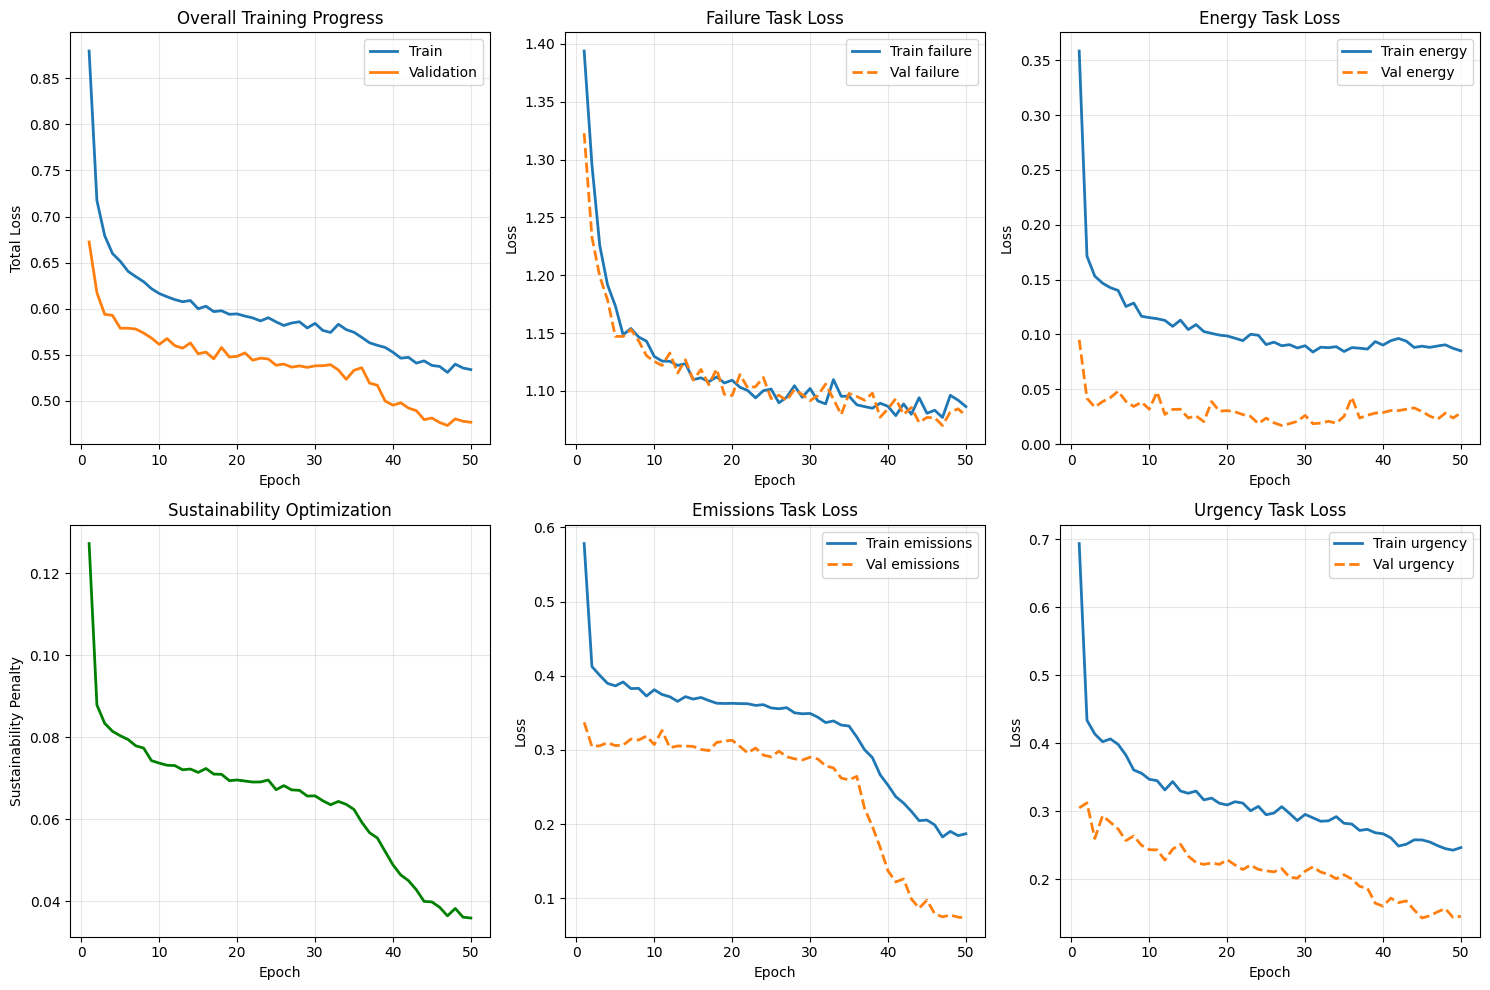

📊 Training history saved to: ../results/multitask_training_history.png


In [7]:
# Visualize Training History

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Extract history data
epochs = range(1, len(history['train']) + 1)

# 1. Total loss
axes[0, 0].plot(epochs, [h['total'] for h in history['train']], label='Train', linewidth=2)
axes[0, 0].plot(epochs, [h['total'] for h in history['val']], label='Validation', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Total Loss')
axes[0, 0].set_title('Overall Training Progress')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Task-specific losses
tasks = ['failure', 'energy', 'emissions', 'urgency']
for i, task in enumerate(tasks):
    row = i // 2
    col = i % 2 + 1
    
    axes[row, col].plot(epochs, [h[task] for h in history['train']], 
                       label=f'Train {task}', linewidth=2)
    axes[row, col].plot(epochs, [h[task] for h in history['val']], 
                       label=f'Val {task}', linewidth=2, linestyle='--')
    axes[row, col].set_xlabel('Epoch')
    axes[row, col].set_ylabel('Loss')
    axes[row, col].set_title(f'{task.capitalize()} Task Loss')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

# 3. Sustainability penalty
axes[1, 0].plot(epochs, [h['sustainability'] for h in history['train']], 
                color='green', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Sustainability Penalty')
axes[1, 0].set_title('Sustainability Optimization')
axes[1, 0].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/multitask_training_history.png', dpi=100, bbox_inches='tight')
plt.show()

print("📊 Training history saved to: ../results/multitask_training_history.png")

In [8]:
# Evaluate Model with Uncertainty

print("\n" + "="*60)
print("🔍 MODEL EVALUATION WITH UNCERTAINTY")
print("="*60)

model.eval()

# Get predictions on test set
test_predictions = []
test_targets = []
test_uncertainties = []

with torch.no_grad():
    for batch_x, batch_y, batch_power_states in test_loader:
        batch_x = batch_x.to(device)
        
        # Get predictions with uncertainty
        uncertainty_preds = model.predict_with_uncertainty(batch_x, n_samples=50)
        
        test_predictions.append({
            'failure': uncertainty_preds['failure_mean'].cpu().numpy(),
            'energy': uncertainty_preds['energy_mean'].cpu().numpy(),
            'emissions': uncertainty_preds['emissions_mean'].cpu().numpy(),
            'urgency': uncertainty_preds['urgency_mean'].cpu().numpy()
        })
        
        test_uncertainties.append({
            'failure': uncertainty_preds['failure_std'].cpu().numpy(),
            'energy': uncertainty_preds['energy_std'].cpu().numpy(),
            'emissions': uncertainty_preds['emissions_std'].cpu().numpy(),
            'urgency': uncertainty_preds['urgency_std'].cpu().numpy()
        })
        
        test_targets.append(batch_y)

# Concatenate all predictions
def concat_predictions(pred_list):
    result = {}
    for key in pred_list[0].keys():
        result[key] = np.concatenate([p[key] for p in pred_list])
    return result

predictions = concat_predictions(test_predictions)
uncertainties = concat_predictions(test_uncertainties)
targets = concat_predictions([{k: v.cpu().numpy() for k, v in t.items()} 
                              for t in test_targets])

# Calculate metrics
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score

print("\n📊 PERFORMANCE METRICS:")
print("-" * 40)

# Failure prediction (classification)
failure_pred_binary = (predictions['failure'] > 0.5).astype(int)
failure_acc = accuracy_score(targets['failure'], failure_pred_binary)
print(f"Failure Detection Accuracy: {failure_acc:.3f}")

# Energy prediction (regression)
energy_mae = mean_absolute_error(targets['energy'], predictions['energy'])
energy_r2 = r2_score(targets['energy'], predictions['energy'])
print(f"Energy MAE: {energy_mae:.3f}, R²: {energy_r2:.3f}")

# Emissions prediction (regression)
emissions_mae = mean_absolute_error(targets['emissions'], predictions['emissions'])
emissions_r2 = r2_score(targets['emissions'], predictions['emissions'])
print(f"Emissions MAE: {emissions_mae:.3f}, R²: {emissions_r2:.3f}")

# Urgency prediction (regression)
urgency_mae = mean_absolute_error(targets['urgency'], predictions['urgency'])
urgency_r2 = r2_score(targets['urgency'], predictions['urgency'])
print(f"Urgency MAE: {urgency_mae:.3f}, R²: {urgency_r2:.3f}")

print("\n📊 UNCERTAINTY QUANTIFICATION:")
print("-" * 40)
for task in ['failure', 'energy', 'emissions', 'urgency']:
    mean_uncertainty = uncertainties[task].mean()
    print(f"{task.capitalize()} avg uncertainty: {mean_uncertainty:.4f}")


🔍 MODEL EVALUATION WITH UNCERTAINTY

📊 PERFORMANCE METRICS:
----------------------------------------
Failure Detection Accuracy: 0.921
Energy MAE: 0.129, R²: 0.976
Emissions MAE: 0.191, R²: 0.936
Urgency MAE: 0.199, R²: 0.866

📊 UNCERTAINTY QUANTIFICATION:
----------------------------------------
Failure avg uncertainty: 0.0826
Energy avg uncertainty: 0.2159
Emissions avg uncertainty: 0.3290
Urgency avg uncertainty: 0.3398


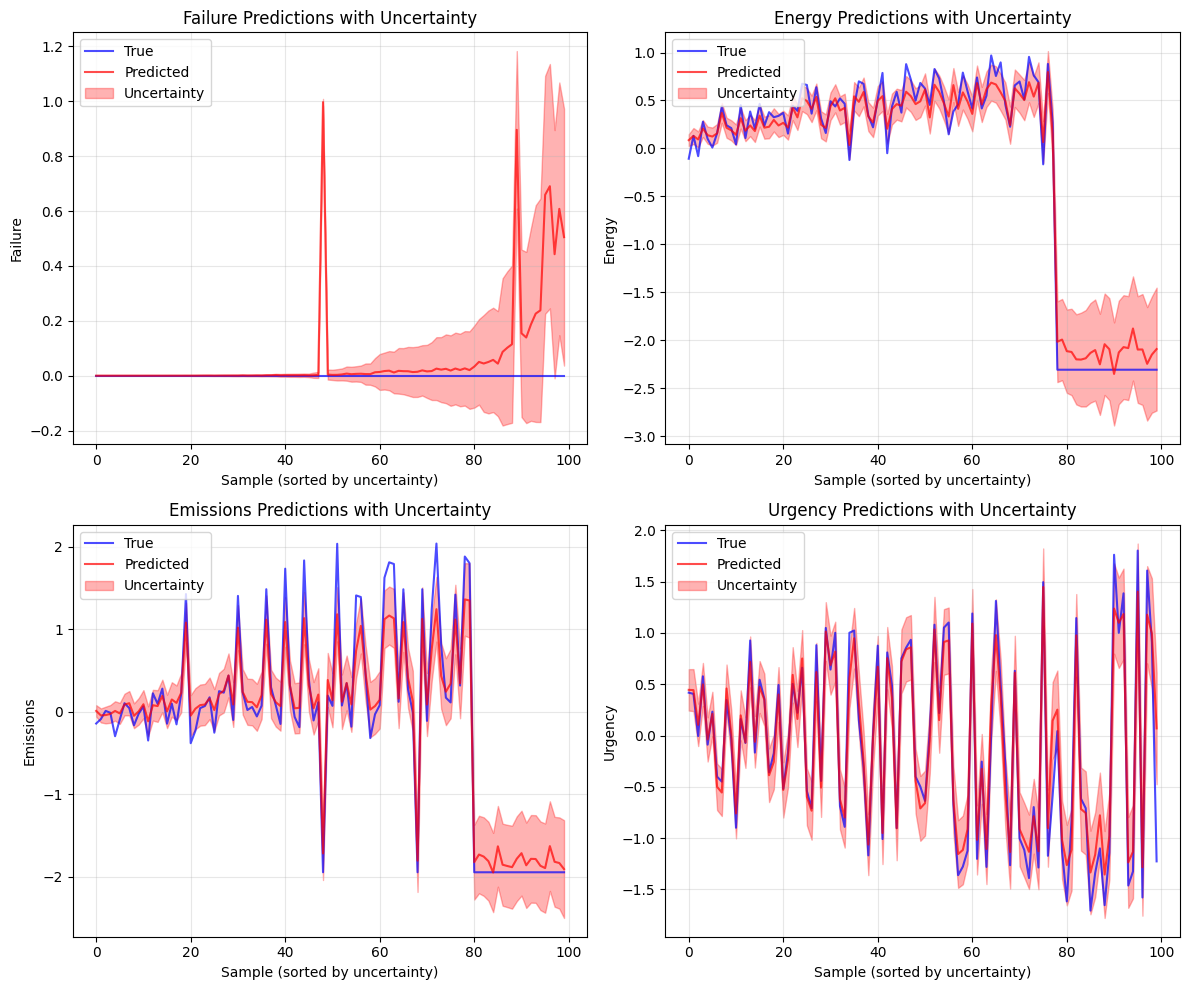

📊 Predictions visualization saved to: ../results/predictions_with_uncertainty.png


In [9]:
# Visualize Predictions with Uncertainty

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Select subset for visualization
n_samples = 100
indices = np.random.choice(len(predictions['failure']), n_samples, replace=False)

for idx, (task, ax) in enumerate(zip(['failure', 'energy', 'emissions', 'urgency'], 
                                     axes.flat)):
    
    # Get subset
    true_vals = targets[task][indices]
    pred_vals = predictions[task][indices]
    uncertainty_vals = uncertainties[task][indices]
    
    # Sort by uncertainty for better visualization
    sort_idx = np.argsort(uncertainty_vals)
    true_vals = true_vals[sort_idx]
    pred_vals = pred_vals[sort_idx]
    uncertainty_vals = uncertainty_vals[sort_idx]
    
    # Plot with uncertainty bands
    x = np.arange(len(true_vals))
    
    # Plot predictions with uncertainty
    ax.plot(x, true_vals, 'b-', label='True', alpha=0.7)
    ax.plot(x, pred_vals, 'r-', label='Predicted', alpha=0.7)
    
    # Add uncertainty bands
    ax.fill_between(x, 
                    pred_vals - uncertainty_vals,
                    pred_vals + uncertainty_vals,
                    alpha=0.3, color='red', label='Uncertainty')
    
    ax.set_xlabel('Sample (sorted by uncertainty)')
    ax.set_ylabel(task.capitalize())
    ax.set_title(f'{task.capitalize()} Predictions with Uncertainty')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/predictions_with_uncertainty.png', dpi=100, bbox_inches='tight')
plt.show()

print("📊 Predictions visualization saved to: ../results/predictions_with_uncertainty.png")


In [11]:
# Save Model and Results

# Save the trained model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'training_history': history,
    'best_val_loss': best_val_loss,
    'metrics': {
        'failure_acc': failure_acc,
        'energy_mae': energy_mae,
        'emissions_mae': emissions_mae,
        'urgency_mae': urgency_mae,
    }
}, '../models/multitask_bayesian_model.pt')

print("💾 Model saved to: ../models/multitask_bayesian_model.pt")

# Save predictions for further analysis
np.savez('../results/test_predictions.npz',
         predictions=predictions,
         targets=targets,
         uncertainties=uncertainties)

print("💾 Predictions saved to: ../results/test_predictions.npz")

💾 Model saved to: ../models/multitask_bayesian_model.pt
💾 Predictions saved to: ../results/test_predictions.npz
